In [34]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

df = load_housing_data()
df = df[:6000]

# Pre-decided data manipulations

### Stratified Train Test Split

In [35]:
import numpy as np
df["income_cat"] = pd.cut(df["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    df, test_size=0.2, stratify=df["income_cat"],
    random_state=42)

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [36]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

### Preprocessing

In [37]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [38]:
from sklearn.neighbors import KNeighborsRegressor

class NeighbourMedianIncome(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y=None):
        X_coords = X.iloc[:, :2]
        y_median_income = X.iloc[:, 2]
        self.model = KNeighborsRegressor(n_neighbors=self.n_neighbors)
        self.model.fit(X_coords, y_median_income)
        return self
    
    def transform(self, X):
        X_coords = X.iloc[:, :2]
        return self.model.predict(X_coords).reshape(-1, 1)
    
    def ger_feature_names_out(self, names=None):
        return ["neighbour_median_income"]


In [39]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=45, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
        ("geo_income", NeighbourMedianIncome(n_neighbors=5), ["latitude", "longitude", "median_income"]),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

# Train a Random Forest Regressor

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
        ("preprocessing", preprocessing), 
        ("random_forest", RandomForestRegressor(max_depth=12, max_features=8, random_state=42))
])

'''best params from RandomizedSearchCV: Best Parameters: {'preprocessing__geo__n_clusters': 45, 'random_forest__max_depth': 12, 'random_forest__max_features': 8}'''

"best params from RandomizedSearchCV: Best Parameters: {'preprocessing__geo__n_clusters': 45, 'random_forest__max_depth': 12, 'random_forest__max_features': 8}"

## Train and Test Scores

In [41]:
from sklearn.model_selection import cross_val_score

-cross_val_score(full_pipeline, housing, housing_labels, cv=3, scoring='neg_root_mean_squared_error')

array([47786.25778626, 51696.36189491, 50532.10177477])

In [42]:
from sklearn.metrics import root_mean_squared_error

full_pipeline.fit(housing, housing_labels)
housing_predictions = full_pipeline.predict(housing)
train_rmse = root_mean_squared_error(housing_labels, housing_predictions)

print(f"Train score: {train_rmse}")

Train score: 27066.603307234185


## Test on the test set

In [43]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = full_pipeline.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

49772.16724535111


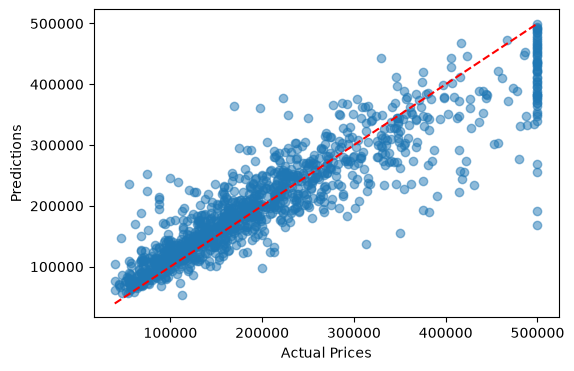

In [44]:
# Plotting Actual vs Predicted values
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(y_test, final_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predictions")
plt.show()